# Evaluator: Visibility Extent (Single Solver Type)

This notebook adapts `evaluator_all_details.ipynb` to the refactored `Visibility_extent.py` experiment. **Generalist/specialist comparisons have been removed**: both sender and receiver crowds use one solver type with bounded `knowledge_breadth`; all dependent variables are measured on the **receiver** crowd.

**Main figures** (following the original 7.2 × 5.0-inch figures, outlined axes, and black line with open-circle markers):
1. Best solution **rank** across visibility extent (lower rank is better; the plotted y-axis is inverted).
2. **Pairwise solution diversity** across visibility extent (mean normalized Hamming distance).
3. **Quality of adopted solutions** across visibility extent (mean *true fitness*, conditional on adoption).

Supplementary figures provide variation across `K`, best solution fitness, unique-solution count, early-extent zooms, adoption-quality trajectories, and extent-by-`K` heatmaps. The notebook also constructs detailed and averaged summary tables, differences from the zero-visibility benchmark, and data-consistency checks.

**Input:** the six pickle output families written by the attached `Visibility_extent.py` script. **No simulation rerun is required.**

## 1. Configuration and methods

- Default experiment: `N=20`, `K=1, ..., 8`, `agent_num=200` in **each** of two crowds, `knowledge_breadth=10`, `search_iteration=300`, and `visibility_interval=10`.
- **Extent** refers to the proportion of sender solvers permanently designated as visible, not the share of receiver solvers receiving a signal. The sender–receiver protocol is fixed throughout the experiment.
- Each saved scalar is **already averaged over 400 landscape repetitions** at a particular `(extent, K)`. Results are averaged across the selected `K` values only for the overall figures. The saved outputs do not contain repetition-level variance, so no confidence intervals or significance tests are estimated.
- `adopted_solution_fitness` is the mean true fitness of receiver-adopted solutions, **conditional on adoption**. It is *undefined*, not zero, when there were no adoptions (typically at extent `0`). The trajectory is the cumulative mean at successive visibility events, not the fitness of adoptions *during* that individual period.

**Edit `result_folder` if the pickle outputs are stored elsewhere.** The notebook first looks for matching results in the current directory and common immediate subfolders. Optional figures and CSVs are saved in a separate `visibility_extent_figures` subfolder.

In [4]:
from pathlib import Path
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Matched to the earlier evaluator notebook.
legend_properties = {'weight': 'bold'}
nus_blue = '#003D7C'
nus_orange = '#EF7C00'
morandi_blue = '#046586'
morandi_green = '#28A9A1'
morandi_yellow = '#C9A77C'
morandi_orange = '#F4A016'
morandi_pink = '#F6BBC6'
morandi_red = '#E71F19'
morandi_purple = '#B08BEB'
shallow_grey = '#D3D4D3'

K_colors = [morandi_blue, morandi_orange, morandi_green, morandi_purple,
            morandi_red, morandi_yellow, '#555555', '#B75F91']


def format_axis(ax):
    """Keep the formatting of the provided evaluator."""
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')
    ax.grid(alpha=0.5)
    ax.tick_params(axis='both', labelsize=11)
    return ax


def safe_nanmean(values, axis=None):
    """Ignore structurally undefined adoption values, retaining all-NaN as NaN."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        return np.nanmean(values, axis=axis)


def finish_figure(fig, filename):
    fig.tight_layout()
    if save_figures:
        figure_folder.mkdir(parents=True, exist_ok=True)
        fig.savefig(figure_folder / filename, dpi=300, bbox_inches='tight', transparent=True)
        print('Saved:', figure_folder / filename)
    plt.show()

In [5]:
# =========================
# Experiment configuration — same as Visibility_extent.py
# =========================
N = 20
agent_num = 200
knowledge_breadth = 10
landscape_iteration = 400  # Documentation only; averages were already computed upstream.
search_iteration = 300
K_list = [1, 2, 3, 4, 5, 6, 7, 8]
visibility_extent_list = [0.0, 0.005, 0.01, 0.02, 0.04, 0.08,
                          0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
visibility_interval = 10

# Choose a subset of K values for the overall figures, if desired.
K_min = 1
K_max = 8
K_indices = [i for i, K in enumerate(K_list) if K_min <= K <= K_max]
if not K_indices:
    raise ValueError('Selected K range is empty. Check K_min and K_max.')

# Change this to the folder containing your new pickle outputs, if auto-detection fails.
result_folder = "/Volumes/T7/data/gst-1010-26/GST/Extent"  # e.g., Path('/Volumes/T7/data/your-new-experiment')

# Set to False to explore data without writing any figures or CSVs.
save_figures = True
save_tables = True
strict_loading = True  # Set False to view partial results from an unfinished run.

candidate_folders = [Path.cwd(), Path.cwd() / 'Results', Path.cwd() / 'results',
                     Path.cwd() / 'output', Path.cwd() / 'data']
expected_example = (f'visibility_extent_{visibility_extent_list[0]}_interval_{visibility_interval}'
                    f'_breakthrough_rank_across_K_size_{agent_num}')

if result_folder is None:
    result_folder = next((folder for folder in candidate_folders
                          if (folder / expected_example).is_file()), Path.cwd())
result_folder = Path(result_folder).expanduser()
figure_folder = result_folder / 'visibility_extent_figures'

print('Result folder:', result_folder)
print('Output folder:', figure_folder)
print('Selected K values:', [K_list[i] for i in K_indices])
print('Example expected file:', expected_example)
print('Folder exists:', result_folder.exists())

Result folder: /Volumes/T7/data/gst-1010-26/GST/Extent
Output folder: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures
Selected K values: [1, 2, 3, 4, 5, 6, 7, 8]
Example expected file: visibility_extent_0.0_interval_10_breakthrough_rank_across_K_size_200
Folder exists: True


## 2. Load and validate the six outcome families

Files follow the *new* name scheme, with **no** G/S condition prefix and **`visibility_extent`** rather than `visibility_prob`:

`visibility_extent_{extent}_interval_{interval}_{DV}_across_K_size_{agent_num}`

The five scalar outcomes load as arrays of shape `(extent, K)`. The adoption-fitness trajectory loads as `(extent, K, visibility event)`. The loader validates shapes, preserves missing or undefined values as `NaN`, and reports absent files without shifting rows out of alignment.

In [6]:
scalar_dvs = [
    'breakthrough_rank',
    'breakthrough_fitness',
    'pairwise_diversity',
    'unique_solution_count',
    'adopted_solution_fitness',
]
trajectory_dv = 'adopted_solution_fitness_across_time'
expected_events = search_iteration // visibility_interval


def result_file(extent, dv):
    filename = (f'visibility_extent_{extent}_interval_{visibility_interval}_'
                f'{dv}_across_K_size_{agent_num}')
    return result_folder / filename


def load_pickle(path):
    with open(path, 'rb') as infile:
        return pickle.load(infile)


def load_visibility_extent_results(strict=True):
    n_extent = len(visibility_extent_list)
    n_K = len(K_list)
    data = {dv: np.full((n_extent, n_K), np.nan) for dv in scalar_dvs}
    data[trajectory_dv] = np.full((n_extent, n_K, expected_events), np.nan)
    missing_files = []
    invalid_files = []

    for i, extent in enumerate(visibility_extent_list):
        for dv in scalar_dvs + [trajectory_dv]:
            path = result_file(extent, dv)
            if not path.is_file():
                missing_files.append(path.name)
                continue
            try:
                values = np.asarray(load_pickle(path), dtype=float)
            except (OSError, pickle.UnpicklingError, TypeError, ValueError) as exc:
                invalid_files.append((path.name, str(exc)))
                continue
            shape = (n_K, expected_events) if dv == trajectory_dv else (n_K,)
            if values.shape != shape:
                invalid_files.append((path.name, f'got {values.shape}; expected {shape}'))
                continue
            data[dv][i] = values

    print(f'Files loaded: {n_extent * 6 - len(missing_files) - len(invalid_files)} / {n_extent * 6}')
    print('Array shapes:', {dv: value.shape for dv, value in data.items()})

    if missing_files:
        print(f'\nMissing files ({len(missing_files)}):')
        for filename in missing_files[:12]:
            print('  ', filename)
        if len(missing_files) > 12:
            print('  ...')
    if invalid_files:
        print(f'\nInvalid files ({len(invalid_files)}):')
        for name, issue in invalid_files[:12]:
            print('  ', name, ':', issue)

    if strict and (missing_files or invalid_files):
        raise FileNotFoundError(
            'Missing/invalid visibility-extent results. Edit result_folder, agent_num, '
            'visibility_interval, the extent grid, or set strict_loading=False '
            'for incomplete runs. First expected file: ' + str(result_file(visibility_extent_list[0], 'breakthrough_rank'))
        )
    if not any(np.isfinite(data[dv]).any() for dv in scalar_dvs):
        raise FileNotFoundError('No valid scalar pickle outputs found in ' + str(result_folder))
    return data


data = load_visibility_extent_results(strict=strict_loading)

Files loaded: 96 / 96
Array shapes: {'breakthrough_rank': (16, 8), 'breakthrough_fitness': (16, 8), 'pairwise_diversity': (16, 8), 'unique_solution_count': (16, 8), 'adopted_solution_fitness': (16, 8), 'adopted_solution_fitness_across_time': (16, 8, 30)}


In [7]:
# =========================
# Data checks and long-form details
# =========================
checks = {
    'breakthrough_rank': (1, 2 ** N),
    'breakthrough_fitness': (0, 1),
    'pairwise_diversity': (0, 1),
    'unique_solution_count': (1, agent_num),
    'adopted_solution_fitness': (0, 1),
}
for dv, (minimum, maximum) in checks.items():
    finite = data[dv][np.isfinite(data[dv])]
    outside = np.count_nonzero((finite < minimum - 1e-8) | (finite > maximum + 1e-8))
    print(f'{dv:29s} finite={finite.size:3d} / {data[dv].size:3d}; outside expected range={outside}')

# The trajectory's final cumulative mean should match the scalar adoption-quality
# measure for each (extent, K), up to floating-point differences.
last_trajectory = data[trajectory_dv][:, :, -1]
both_defined = np.isfinite(last_trajectory) & np.isfinite(data['adopted_solution_fitness'])
if both_defined.any():
    gap = np.max(np.abs(last_trajectory[both_defined] - data['adopted_solution_fitness'][both_defined]))
    print('Max discrepancy: final trajectory vs. scalar adoption quality =', round(float(gap), 12))

rows = []
for i, extent in enumerate(visibility_extent_list):
    for j, K in enumerate(K_list):
        row = {'visibility_extent': extent, 'K': K}
        for dv in scalar_dvs:
            row[dv] = data[dv][i, j]
        rows.append(row)

detailed_results = pd.DataFrame(rows)
print('\nDetailed data preview (one observation per extent × K):')
display(detailed_results.head(12).round(4))

breakthrough_rank             finite=128 / 128; outside expected range=0
breakthrough_fitness          finite=128 / 128; outside expected range=0
pairwise_diversity            finite=128 / 128; outside expected range=0
unique_solution_count         finite=128 / 128; outside expected range=0
adopted_solution_fitness      finite=120 / 128; outside expected range=0
Max discrepancy: final trajectory vs. scalar adoption quality = 0.0

Detailed data preview (one observation per extent × K):


,visibility_extent,K,breakthrough_rank,breakthrough_fitness,pairwise_diversity,unique_solution_count,adopted_solution_fitness
0,0.000,1,55.2025,0.9612,0.4478,199.5400,NaN
1,0.000,2,64.6375,0.9492,0.4786,199.7100,NaN
2,0.000,3,70.5975,0.9358,0.4915,199.7225,NaN
3,0.000,4,81.6650,0.9282,0.4958,199.8075,NaN
4,0.000,5,81.0475,0.9232,0.4982,199.8075,NaN
5,0.000,6,78.0400,0.9215,0.4992,199.8250,NaN
6,0.000,7,85.4025,0.9190,0.4996,199.8700,NaN
7,0.000,8,99.7900,0.9112,0.4998,199.8600,NaN
8,0.005,1,47.1750,0.9658,0.3972,171.8350,0.6704
9,0.005,2,60.3125,0.9506,0.4286,174.9175,0.6536


## 3. Main results: visibility extent

These **overall** figures average each saved landscape-repetition mean equally across the selected `K` values. This matches the averaged-line design of the source evaluator, now without averaging over G/S pairings. To inspect heterogeneity across landscape complexity, use the adjacent **by-`K`** figures. The line connects experimentally sampled extents (the points are not equally spaced on the horizontal axis).

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig1_average_breakthrough_rank_K1_to_K8.png


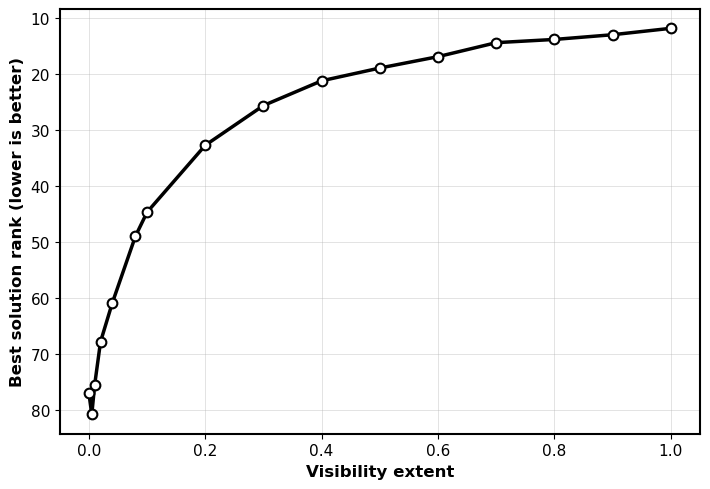

In [8]:
# Figure 1: Best solution rank across visibility extent (overall K average).
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)
x = np.asarray(visibility_extent_list)
y_rank = safe_nanmean(data['breakthrough_rank'][:, K_indices], axis=1)
ax.plot(x, y_rank, marker='o', linewidth=2.5, markersize=7, color='k',
        markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.5)
ax.invert_yaxis()  # Rank 1 is best; invert so a better rank is visually higher.
ax.set_xlabel('Visibility extent', fontweight='bold', fontsize=12)
ax.set_ylabel('Best solution rank (lower is better)', fontweight='bold', fontsize=12)
finish_figure(fig, f'fig1_average_breakthrough_rank_K{K_min}_to_K{K_max}.png')

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig2_breakthrough_rank_by_K.png


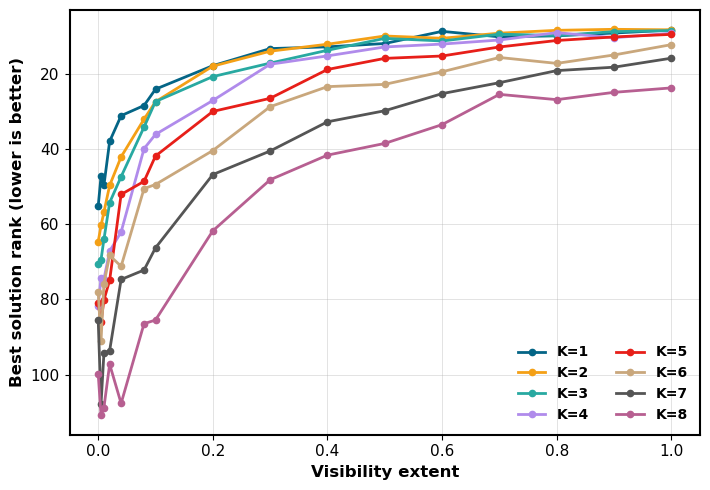

In [9]:
# Figure 2: Best solution rank — separate curves by K (no solver-type splits).
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)
for color_index, j in enumerate(K_indices):
    ax.plot(visibility_extent_list, data['breakthrough_rank'][:, j],
            marker='o', linewidth=2.0, markersize=4.5,
            label=f'K={K_list[j]}', color=K_colors[j % len(K_colors)])
ax.invert_yaxis()
ax.set_xlabel('Visibility extent', fontweight='bold', fontsize=12)
ax.set_ylabel('Best solution rank (lower is better)', fontweight='bold', fontsize=12)
ax.legend(frameon=False, ncol=2, prop={'weight': 'bold', 'size': 10})
finish_figure(fig, 'fig2_breakthrough_rank_by_K.png')

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig3_average_pairwise_diversity_K1_to_K8.png


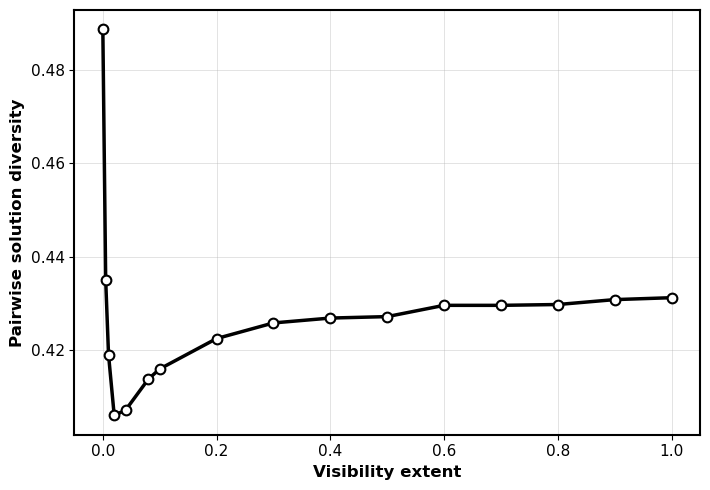

In [10]:
# Figure 3: Pairwise solution diversity across visibility extent (overall K average).
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)
y_diversity = safe_nanmean(data['pairwise_diversity'][:, K_indices], axis=1)
ax.plot(x, y_diversity, marker='o', linewidth=2.5, markersize=7, color='k',
        markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.5)
ax.set_xlabel('Visibility extent', fontweight='bold', fontsize=12)
ax.set_ylabel('Pairwise solution diversity', fontweight='bold', fontsize=12)
finish_figure(fig, f'fig3_average_pairwise_diversity_K{K_min}_to_K{K_max}.png')

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig4_pairwise_diversity_by_K.png


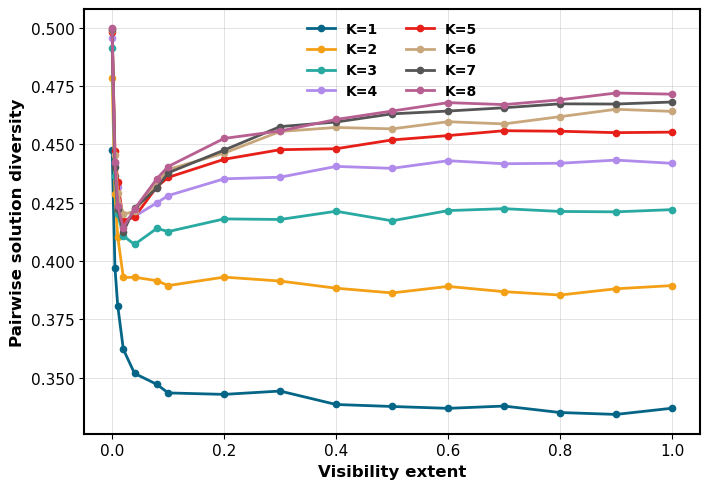

In [11]:
# Figure 4: Pairwise solution diversity by K.
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)
for j in K_indices:
    ax.plot(visibility_extent_list, data['pairwise_diversity'][:, j],
            marker='o', linewidth=2.0, markersize=4.5,
            label=f'K={K_list[j]}', color=K_colors[j % len(K_colors)])
ax.set_xlabel('Visibility extent', fontweight='bold', fontsize=12)
ax.set_ylabel('Pairwise solution diversity', fontweight='bold', fontsize=12)
ax.legend(frameon=False, ncol=2, prop={'weight': 'bold', 'size': 10})
finish_figure(fig, 'fig4_pairwise_diversity_by_K.png')

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig5_average_adopted_solution_fitness_K1_to_K8.png


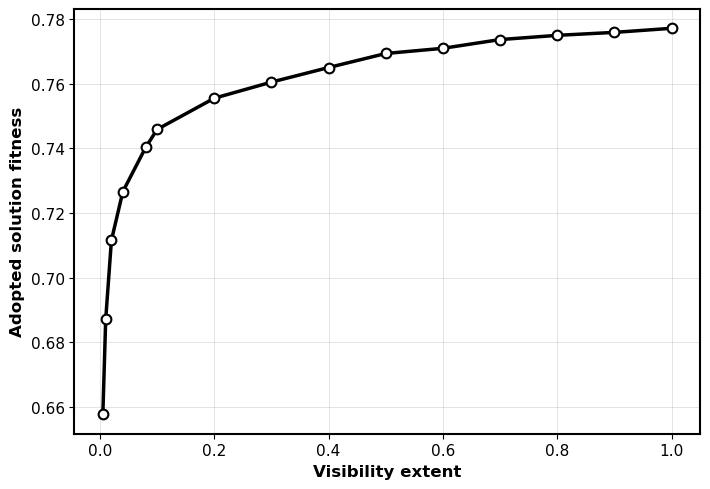

In [12]:
# Figure 5: Mean true fitness of adopted solutions, conditional on adoption.
# Undefined outcomes (including v=0) stay NaN and are not shown as zero.
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)
y_adopted = safe_nanmean(data['adopted_solution_fitness'][:, K_indices], axis=1)
ax.plot(x, y_adopted, marker='o', linewidth=2.5, markersize=7, color='k',
        markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.5)
ax.set_xlabel('Visibility extent', fontweight='bold', fontsize=12)
ax.set_ylabel('Adopted solution fitness', fontweight='bold', fontsize=12)
finish_figure(fig, f'fig5_average_adopted_solution_fitness_K{K_min}_to_K{K_max}.png')

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig6_adopted_solution_fitness_by_K.png


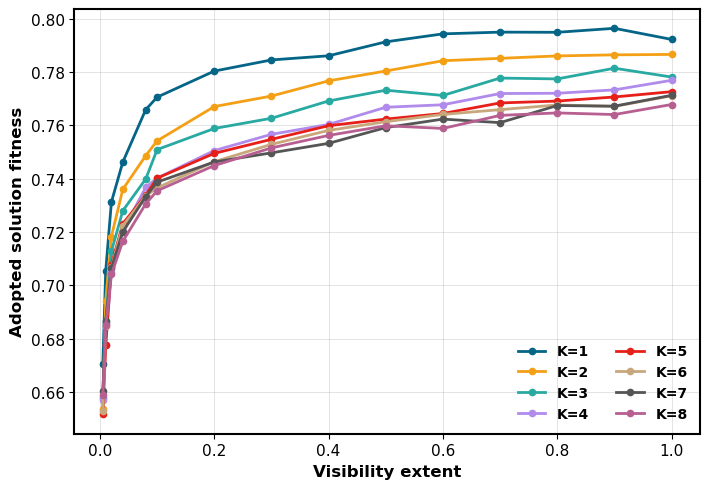

In [13]:
# Figure 6: Adopted-solution quality by K (NaNs remain missing).
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)
for j in K_indices:
    ax.plot(visibility_extent_list, data['adopted_solution_fitness'][:, j],
            marker='o', linewidth=2.0, markersize=4.5,
            label=f'K={K_list[j]}', color=K_colors[j % len(K_colors)])
ax.set_xlabel('Visibility extent', fontweight='bold', fontsize=12)
ax.set_ylabel('Adopted solution fitness', fontweight='bold', fontsize=12)
ax.legend(frameon=False, ncol=2, prop={'weight': 'bold', 'size': 10})
finish_figure(fig, 'fig6_adopted_solution_fitness_by_K.png')

### Fine-grained changes at low visibility

The experiment deliberately samples extent more densely close to zero (`0`, `0.005`, `0.01`, ...). These magnified versions use the **same computed overall averages** and display only `extent ≤ early_extent_max` so any abrupt initial response is easier to see.

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig7_early_extent_rank.png


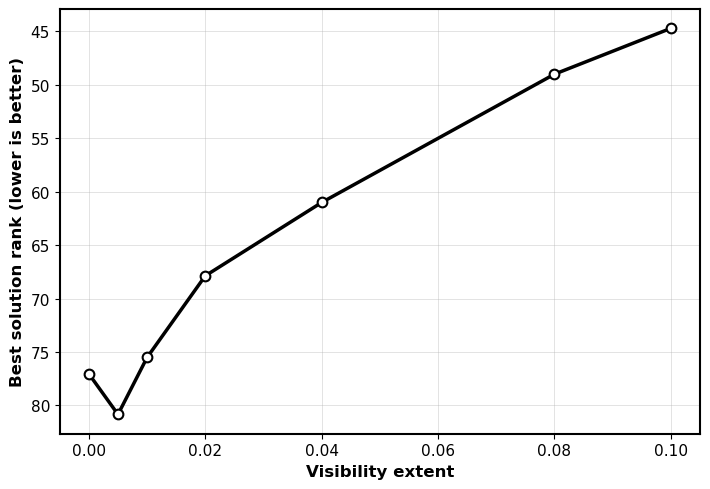

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig8_early_extent_pairwise_diversity.png


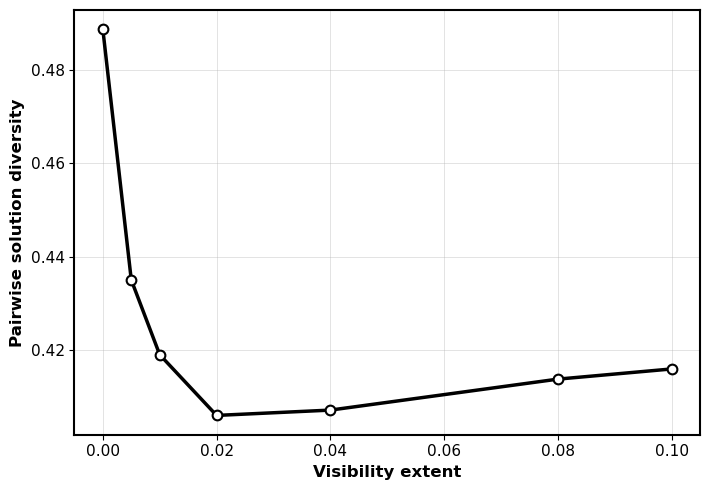

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig9_early_extent_adopted_quality.png


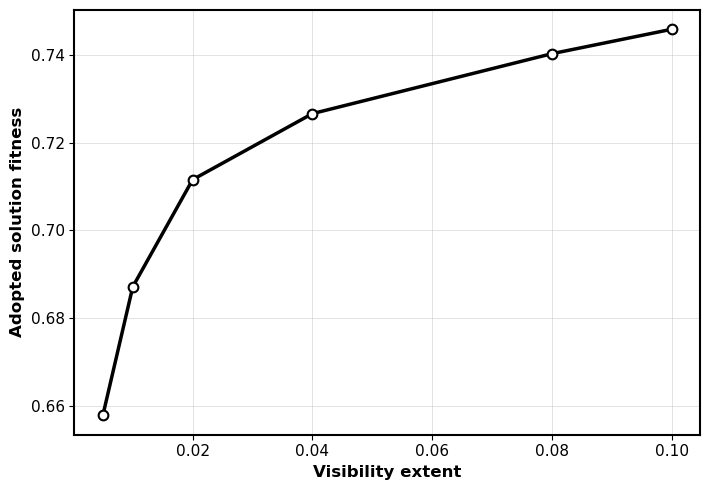

In [14]:
early_extent_max = 0.1
mask = x <= early_extent_max
for dv, ylabel, filename, invert in [
    ('breakthrough_rank', 'Best solution rank (lower is better)', 'fig7_early_extent_rank.png', True),
    ('pairwise_diversity', 'Pairwise solution diversity', 'fig8_early_extent_pairwise_diversity.png', False),
    ('adopted_solution_fitness', 'Adopted solution fitness', 'fig9_early_extent_adopted_quality.png', False),
]:
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    format_axis(ax)
    curve = safe_nanmean(data[dv][:, K_indices], axis=1)
    ax.plot(x[mask], curve[mask], marker='o', linewidth=2.5, markersize=7,
            color='k', markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.5)
    if invert:
        ax.invert_yaxis()
    ax.set_xlabel('Visibility extent', fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=12)
    finish_figure(fig, filename)

## 4. Additional outcomes

`breakthrough_fitness` is the highest final receiver-solution fitness within a repetition; `breakthrough_rank` is the best final receiver solution's rank in the landscape. These are related but distinct summary scales. `unique_solution_count` captures the number of distinct final receiver solutions, whereas **pairwise diversity** captures how different those solutions are, even when uniqueness coincides.

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig10_average_breakthrough_fitness.png


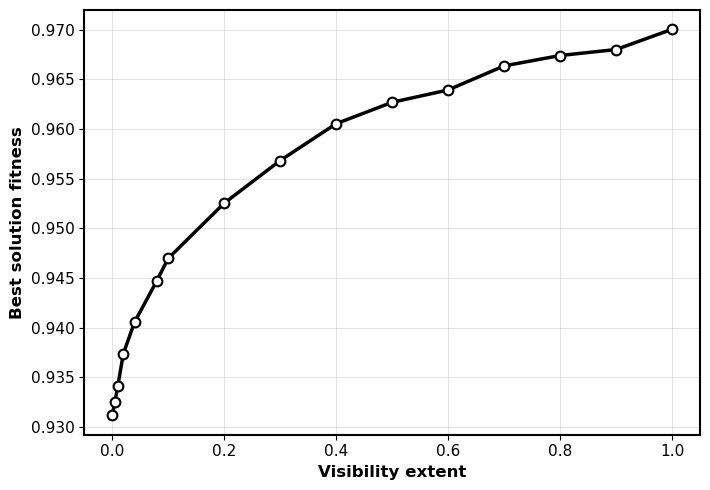

In [15]:
# Figure 10: Best receiver solution fitness across visibility extent.
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)
y_fitness = safe_nanmean(data['breakthrough_fitness'][:, K_indices], axis=1)
ax.plot(x, y_fitness, marker='o', linewidth=2.5, markersize=7, color='k',
        markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.5)
ax.set_xlabel('Visibility extent', fontweight='bold', fontsize=12)
ax.set_ylabel('Best solution fitness', fontweight='bold', fontsize=12)
finish_figure(fig, 'fig10_average_breakthrough_fitness.png')

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig11_average_unique_solution_count.png


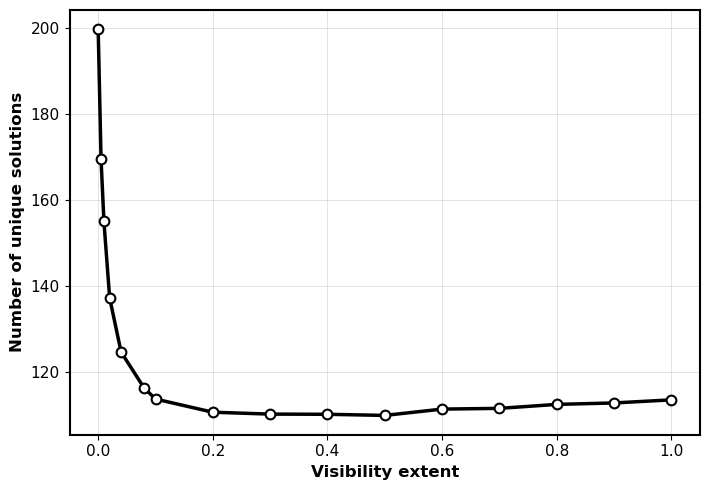

In [16]:
# Figure 11: Unique final receiver solutions across visibility extent.
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)
y_unique = safe_nanmean(data['unique_solution_count'][:, K_indices], axis=1)
ax.plot(x, y_unique, marker='o', linewidth=2.5, markersize=7, color='k',
        markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.5)
ax.set_xlabel('Visibility extent', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of unique solutions', fontweight='bold', fontsize=12)
finish_figure(fig, 'fig11_average_unique_solution_count.png')

## 5. Adoption-quality trajectories across search time

The original evaluator's trajectory analysis is retained without the G/S splitting. Set `trajectory_visibility_extent` to any sampled extent, and optionally adjust the `K` averaging range above. The horizontal axis reports actual search periods (`10, 20, ..., 300` by default). Each ordinate is the **cumulative mean quality of adopted solutions through that event**; it is not period-specific adoption quality or the mean quality of all receiver solutions.

In [17]:
trajectory_visibility_extent = 1.0  # Change to any entry in visibility_extent_list.
if trajectory_visibility_extent not in visibility_extent_list:
    raise ValueError('trajectory_visibility_extent must appear in visibility_extent_list.')
trajectory_index = visibility_extent_list.index(trajectory_visibility_extent)
trajectory_periods = (np.arange(1, expected_events + 1) * visibility_interval)
trajectory_by_K = data[trajectory_dv][trajectory_index]  # (K, visibility event)
print('Trajectory extent:', trajectory_visibility_extent)
print('Visibility events:', len(trajectory_periods), '| last search period:', trajectory_periods[-1])
print('Defined trajectory entries:', np.isfinite(trajectory_by_K).sum(), '/', trajectory_by_K.size)

Trajectory extent: 1.0
Visibility events: 30 | last search period: 300
Defined trajectory entries: 240 / 240


Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig12_average_adoption_trajectory_extent_1.0.png


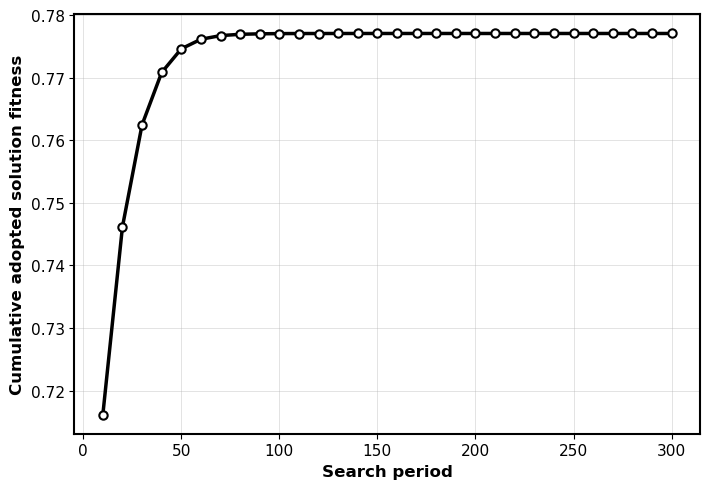

In [18]:
# Figure 12: Cumulative adopted-solution fitness — averaged across selected K.
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)
trajectory_mean = safe_nanmean(trajectory_by_K[K_indices], axis=0)
ax.plot(trajectory_periods, trajectory_mean, marker='o', linewidth=2.5,
        markersize=6, color='k', markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.5)
ax.set_xlabel('Search period', fontweight='bold', fontsize=12)
ax.set_ylabel('Cumulative adopted solution fitness', fontweight='bold', fontsize=12)
finish_figure(fig, f'fig12_average_adoption_trajectory_extent_{trajectory_visibility_extent}.png')

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig13_adoption_trajectory_by_K_extent_1.0.png


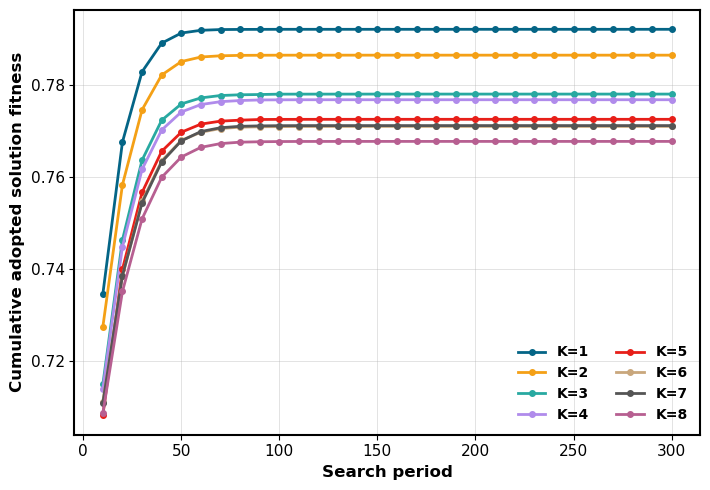

In [19]:
# Figure 13: Same cumulative trajectory, one line per K.
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)
for j in K_indices:
    ax.plot(trajectory_periods, trajectory_by_K[j], marker='o',
            linewidth=2.0, markersize=4, color=K_colors[j % len(K_colors)],
            label=f'K={K_list[j]}')
ax.set_xlabel('Search period', fontweight='bold', fontsize=12)
ax.set_ylabel('Cumulative adopted solution fitness', fontweight='bold', fontsize=12)
ax.legend(frameon=False, ncol=2, prop={'weight': 'bold', 'size': 10})
finish_figure(fig, f'fig13_adoption_trajectory_by_K_extent_{trajectory_visibility_extent}.png')

## 6. Visibility × landscape complexity

These heatmaps display the underlying saved `(extent, K)` averages without pooling across `K`. `NaN` cells remain blank, especially for adoption quality at zero visibility. They help diagnose whether an overall trend is stable or masks heterogeneous responses across landscape complexity.

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig14_heatmap_breakthrough_rank.png


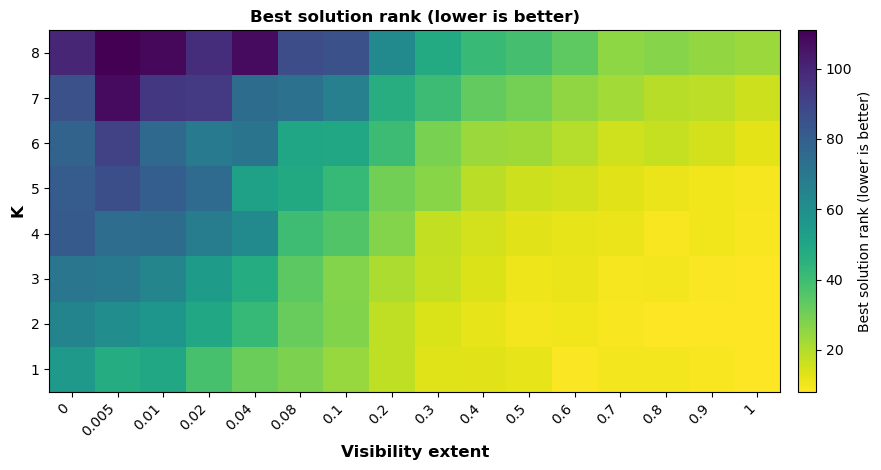

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig15_heatmap_pairwise_diversity.png


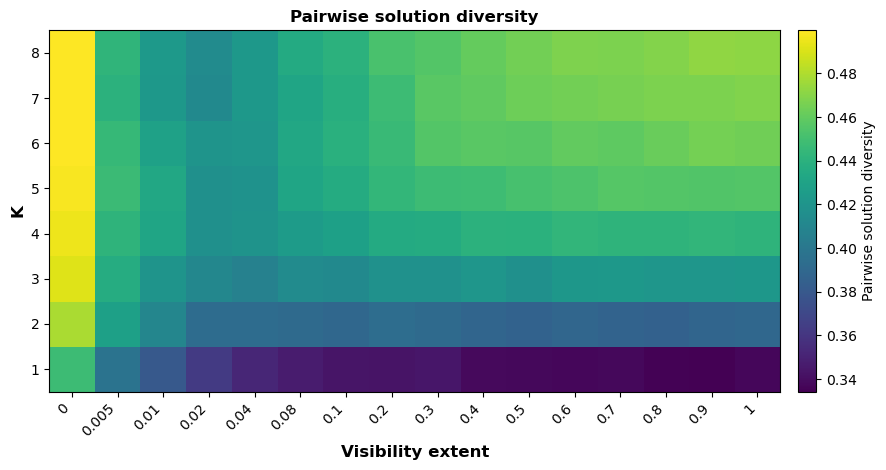

Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/fig16_heatmap_adopted_solution_fitness.png


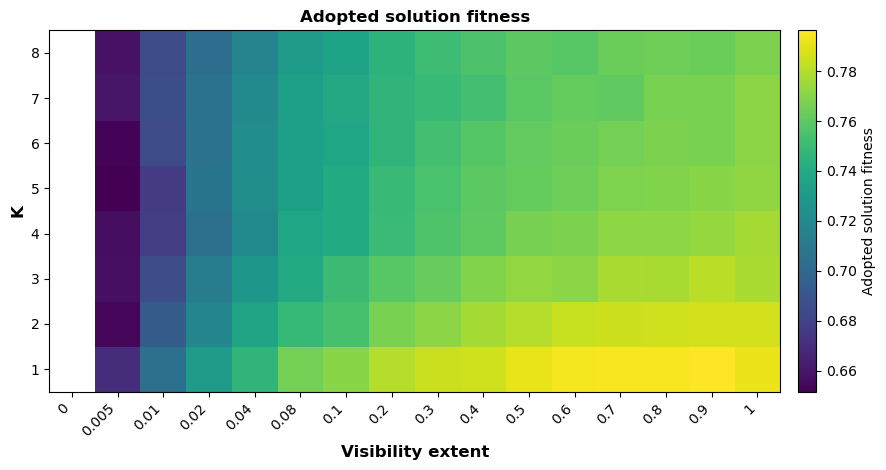

In [20]:
for dv, title, filename, cmap, invert_color in [
    ('breakthrough_rank', 'Best solution rank (lower is better)', 'fig14_heatmap_breakthrough_rank.png', 'viridis_r', False),
    ('pairwise_diversity', 'Pairwise solution diversity', 'fig15_heatmap_pairwise_diversity.png', 'viridis', False),
    ('adopted_solution_fitness', 'Adopted solution fitness', 'fig16_heatmap_adopted_solution_fitness.png', 'viridis', False),
]:
    values = np.ma.masked_invalid(data[dv].T)  # (K, extent)
    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    image = ax.imshow(values, aspect='auto', interpolation='nearest', cmap=cmap, origin='lower')
    ax.set_xticks(np.arange(len(visibility_extent_list)))
    ax.set_xticklabels([f'{extent:g}' for extent in visibility_extent_list], rotation=45, ha='right')
    ax.set_yticks(np.arange(len(K_list)))
    ax.set_yticklabels(K_list)
    ax.set_xlabel('Visibility extent', fontweight='bold', fontsize=12)
    ax.set_ylabel('K', fontweight='bold', fontsize=12)
    ax.set_title(title, fontweight='bold', fontsize=12)
    fig.colorbar(image, ax=ax, label=title, pad=0.02)
    finish_figure(fig, filename)

## 7. Detailed output analysis and baseline comparisons

The following tables retain every `(visibility extent, K)` pair, as well as an average across the selected `K` values. For final-state outcomes, the differences subtract the **independent-search benchmark** (`extent = 0`) *within the same K*. For rank, **negative differences indicate an improvement**; for best fitness, diversity, and unique count, positive differences indicate an increase. Adoption-quality differences from `extent = 0` are intentionally excluded because adopted-solution fitness is generally undefined without visibility.

In [21]:
# Across-K summary, with a count of K values contributing to each outcome.
summary_rows = []
for i, extent in enumerate(visibility_extent_list):
    row = {'visibility_extent': extent}
    for dv in scalar_dvs:
        selected = data[dv][i, K_indices]
        row[dv] = safe_nanmean(selected)
        row[f'{dv}_n_K'] = int(np.isfinite(selected).sum())
    summary_rows.append(row)
summary_table = pd.DataFrame(summary_rows)

print('Averages across selected K values:')
display(summary_table[['visibility_extent'] + scalar_dvs].round(4))

print('Number of defined K cells contributing to each average:')
display(summary_table[['visibility_extent'] + [f'{dv}_n_K' for dv in scalar_dvs]])

Averages across selected K values:


,visibility_extent,breakthrough_rank,breakthrough_fitness,pairwise_diversity,unique_solution_count,adopted_solution_fitness
0,0.000,77.0478,0.9312,0.4888,199.7678,NaN
1,0.005,80.8353,0.9325,0.4350,169.4906,0.6578
2,0.010,75.5109,0.9341,0.4190,154.9912,0.6871
3,0.020,67.8775,0.9374,0.4059,137.1762,0.7115
4,0.040,61.0203,0.9406,0.4071,124.5553,0.7266
5,0.080,49.0238,0.9447,0.4137,116.2147,0.7403
6,0.100,44.7372,0.9470,0.4159,113.6175,0.7458
7,0.200,32.7941,0.9525,0.4224,110.5434,0.7555
8,0.300,25.6991,0.9568,0.4258,110.1038,0.7604
9,0.400,21.2859,0.9605,0.4268,110.0612,0.7649


Number of defined K cells contributing to each average:


,visibility_extent,breakthrough_rank_n_K,breakthrough_fitness_n_K,pairwise_diversity_n_K,unique_solution_count_n_K,adopted_solution_fitness_n_K
0,0.000,8,8,8,8,0
1,0.005,8,8,8,8,8
2,0.010,8,8,8,8,8
3,0.020,8,8,8,8,8
4,0.040,8,8,8,8,8
5,0.080,8,8,8,8,8
6,0.100,8,8,8,8,8
7,0.200,8,8,8,8,8
8,0.300,8,8,8,8,8
9,0.400,8,8,8,8,8


In [22]:
# Differences relative to extent=0, evaluated within the same K first.
benchmark_metrics = ['breakthrough_rank', 'breakthrough_fitness',
                     'pairwise_diversity', 'unique_solution_count']
comparison_table = detailed_results.copy()
baseline = detailed_results.loc[detailed_results['visibility_extent'] == 0].set_index('K')
if len(baseline) != len(K_list):
    raise ValueError('Extent=0 must be included in the experiment for benchmark comparisons.')
for dv in benchmark_metrics:
    comparison_table[f'delta_{dv}'] = (comparison_table[dv] -
                                     comparison_table['K'].map(baseline[dv]))

average_deltas = (comparison_table[comparison_table['K'].isin([K_list[j] for j in K_indices])]
                  .groupby('visibility_extent', sort=True)[
                      [f'delta_{dv}' for dv in benchmark_metrics]].mean().reset_index())
print('Average change relative to independent search (extent=0), same K:')
display(average_deltas.round(4))

print('Example detailed records with absolute metrics and differences:')
display(comparison_table.head(16).round(4))

Average change relative to independent search (extent=0), same K:


,visibility_extent,delta_breakthrough_rank,delta_breakthrough_fitness,delta_pairwise_diversity,delta_unique_solution_count
0,0.000,0.0000,0.0000,0.0000,0.0000
1,0.005,3.7875,0.0014,-0.0538,-30.2772
2,0.010,-1.5369,0.0029,-0.0698,-44.7766
3,0.020,-9.1703,0.0062,-0.0829,-62.5916
4,0.040,-16.0275,0.0094,-0.0817,-75.2125
5,0.080,-28.0241,0.0136,-0.0751,-83.5531
6,0.100,-32.3106,0.0158,-0.0729,-86.1503
7,0.200,-44.2538,0.0214,-0.0664,-89.2244
8,0.300,-51.3488,0.0257,-0.0630,-89.6641
9,0.400,-55.7619,0.0294,-0.0620,-89.7066


Example detailed records with absolute metrics and differences:


,visibility_extent,K,breakthrough_rank,breakthrough_fitness,pairwise_diversity,unique_solution_count,adopted_solution_fitness,delta_breakthrough_rank,delta_breakthrough_fitness,delta_pairwise_diversity,delta_unique_solution_count
0,0.000,1,55.2025,0.9612,0.4478,199.5400,NaN,0.0000,0.0000,0.0000,0.0000
1,0.000,2,64.6375,0.9492,0.4786,199.7100,NaN,0.0000,0.0000,0.0000,0.0000
2,0.000,3,70.5975,0.9358,0.4915,199.7225,NaN,0.0000,0.0000,0.0000,0.0000
3,0.000,4,81.6650,0.9282,0.4958,199.8075,NaN,0.0000,0.0000,0.0000,0.0000
4,0.000,5,81.0475,0.9232,0.4982,199.8075,NaN,0.0000,0.0000,0.0000,0.0000
5,0.000,6,78.0400,0.9215,0.4992,199.8250,NaN,0.0000,0.0000,0.0000,0.0000
6,0.000,7,85.4025,0.9190,0.4996,199.8700,NaN,0.0000,0.0000,0.0000,0.0000
7,0.000,8,99.7900,0.9112,0.4998,199.8600,NaN,0.0000,0.0000,0.0000,0.0000
8,0.005,1,47.1750,0.9658,0.3972,171.8350,0.6704,-8.0275,0.0046,-0.0506,-27.7050
9,0.005,2,60.3125,0.9506,0.4286,174.9175,0.6536,-4.3250,0.0014,-0.0499,-24.7925


In [23]:
# A concise K-sensitive comparison at a few user-selectable extents.
comparison_extents = [0.0, 0.01, 0.1, 0.5, 1.0]
comparison_extents = [v for v in comparison_extents if v in visibility_extent_list]
selected_dvs = ['breakthrough_rank', 'pairwise_diversity',
                'adopted_solution_fitness', 'breakthrough_fitness', 'unique_solution_count']
for extent in comparison_extents:
    print(f'Visibility extent = {extent:g}')
    display(detailed_results.loc[detailed_results['visibility_extent'] == extent,
                                 ['K'] + selected_dvs].round(4).set_index('K'))

Visibility extent = 0


,breakthrough_rank,pairwise_diversity,adopted_solution_fitness,breakthrough_fitness,unique_solution_count
K,,,,,
1,55.2025,0.4478,NaN,0.9612,199.5400
2,64.6375,0.4786,NaN,0.9492,199.7100
3,70.5975,0.4915,NaN,0.9358,199.7225
4,81.6650,0.4958,NaN,0.9282,199.8075
5,81.0475,0.4982,NaN,0.9232,199.8075
6,78.0400,0.4992,NaN,0.9215,199.8250
7,85.4025,0.4996,NaN,0.9190,199.8700
8,99.7900,0.4998,NaN,0.9112,199.8600


Visibility extent = 0.01


,breakthrough_rank,pairwise_diversity,adopted_solution_fitness,breakthrough_fitness,unique_solution_count
K,,,,,
1,49.6400,0.3808,0.7053,0.9656,160.3200
2,56.7850,0.4104,0.6942,0.9562,161.2600
3,64.0450,0.4202,0.6858,0.9432,160.3650
4,74.5950,0.4317,0.6776,0.9324,160.1450
5,80.1650,0.4337,0.6775,0.9234,156.3475
6,75.7875,0.4290,0.6847,0.9235,151.8050
7,94.2950,0.4223,0.6866,0.9170,146.0425
8,108.7750,0.4234,0.6850,0.9115,143.6450


Visibility extent = 0.1


,breakthrough_rank,pairwise_diversity,adopted_solution_fitness,breakthrough_fitness,unique_solution_count
K,,,,,
1,24.0550,0.3435,0.7706,0.9788,124.5575
2,27.3925,0.3895,0.7542,0.9673,125.8900
3,27.3450,0.4126,0.7509,0.9608,125.0675
4,36.0850,0.4281,0.7402,0.9487,120.3525
5,41.8400,0.4358,0.7402,0.9419,113.5925
6,49.4175,0.4393,0.7365,0.9331,107.4800
7,66.2775,0.4378,0.7387,0.9272,98.9650
8,85.4850,0.4405,0.7354,0.9180,93.0350


Visibility extent = 0.5


,breakthrough_rank,pairwise_diversity,adopted_solution_fitness,breakthrough_fitness,unique_solution_count
K,,,,,
1,11.8950,0.3377,0.7913,0.9848,121.8625
2,9.8975,0.3863,0.7804,0.9825,123.7675
3,10.5350,0.4173,0.7732,0.9747,120.2875
4,12.8125,0.4397,0.7668,0.9678,116.3925
5,15.8525,0.4519,0.7623,0.9594,109.7475
6,22.7700,0.4567,0.7613,0.9493,101.9050
7,29.7875,0.4631,0.7591,0.9456,96.3050
8,38.4825,0.4643,0.7598,0.9375,88.1150


Visibility extent = 1


,breakthrough_rank,pairwise_diversity,adopted_solution_fitness,breakthrough_fitness,unique_solution_count
K,,,,,
1,8.3175,0.3369,0.7922,0.9882,128.7250
2,8.2525,0.3895,0.7866,0.9829,127.3175
3,8.4400,0.4220,0.7781,0.9795,124.1550
4,9.1575,0.4419,0.7769,0.9731,118.8875
5,9.4650,0.4553,0.7726,0.9702,112.1500
6,12.2025,0.4642,0.7711,0.9630,105.4475
7,15.8025,0.4682,0.7712,0.9555,97.3200
8,23.7100,0.4715,0.7678,0.9479,93.3725


## 8. Diagnostics and export

The experiment saves **aggregated means**, not individual replication records, so the evaluator cannot reconstruct replicate distributions, standard errors, adoption rates, or the number of adopted solutions. In particular, `NaN` adoption quality does *not* mean zero-fitness adoption, and a non-`NaN` value does not reveal how often adoption occurred. For inferential comparisons, the simulation would need to save repetition-level outcomes separately.

In [24]:
# Final integrity checks and a compact computed summary of the primary curves.
for dv, label, lower_better in [
    ('breakthrough_rank', 'Best rank', True),
    ('pairwise_diversity', 'Pairwise diversity', False),
    ('adopted_solution_fitness', 'Adopted-solution quality', False),
]:
    means = safe_nanmean(data[dv][:, K_indices], axis=1)
    valid = np.flatnonzero(np.isfinite(means))
    if not len(valid):
        print(label + ': no defined observations')
        continue
    best_idx = valid[np.argmin(means[valid]) if lower_better else np.argmax(means[valid])]
    first_idx, last_idx = valid[0], valid[-1]
    print(f'{label}: first defined extent={x[first_idx]:g}, mean={means[first_idx]:.4f}; '
          f'last extent={x[last_idx]:g}, mean={means[last_idx]:.4f}; '
          f'{"best" if lower_better else "highest"} at extent={x[best_idx]:g} ({means[best_idx]:.4f})')

if save_tables:
    figure_folder.mkdir(parents=True, exist_ok=True)
    for filename, table in [
        ('visibility_extent_detailed_by_K.csv', detailed_results),
        ('visibility_extent_K_averaged.csv', summary_table),
        ('visibility_extent_baseline_differences_by_K.csv', comparison_table),
        ('visibility_extent_baseline_differences_K_averaged.csv', average_deltas),
    ]:
        table.to_csv(figure_folder / filename, index=False)
        print('Saved:', figure_folder / filename)

Best rank: first defined extent=0, mean=77.0478; last extent=1, mean=11.9184; best at extent=1 (11.9184)
Pairwise diversity: first defined extent=0, mean=0.4888; last extent=1, mean=0.4312; highest at extent=0 (0.4888)
Adopted-solution quality: first defined extent=0.005, mean=0.6578; last extent=1, mean=0.7771; highest at extent=1 (0.7771)
Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/visibility_extent_detailed_by_K.csv
Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/visibility_extent_K_averaged.csv
Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/visibility_extent_baseline_differences_by_K.csv
Saved: /Volumes/T7/data/gst-1010-26/GST/Extent/visibility_extent_figures/visibility_extent_baseline_differences_K_averaged.csv


### Interpretation guide

Read the best-rank curve, pairwise diversity curve, and adopted-solution-quality curve **together**. Greater visibility may alter the spatial dispersion of final receiver solutions and the quality of solutions selected through visibility; these dimensions need not move in the same direction. Check the by-`K` figures before describing any overall association as uniform across landscapes.

The saved measures characterize **final breakthroughs and diversity**, and the **true fitness of solutions adopted during search**. They do not, by themselves, identify causal mediation, the number of adoption events, or confidence intervals. In this notebook, plotted lines are descriptive summaries of the simulation outputs rather than fitted response functions.